<a href="https://colab.research.google.com/github/Bhavya1835/Stochastic-Interest-Rate-Modelling-and-Prediction/blob/main/Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stochastic Interest Rate Modelling and Prediction
Hello Reviewing Team! I will be explaining the mechanics of the implementation in the text blocks that follow along this notebook. To run the model and get results yourself, **execute all code blocks top to down sequentially**
### **Project Overview & Methodology**
**4 Step Implementation:**
1. **Data Engineering:** Constructed a mathematically viable time-series by neutralizing outliers and ensuring strict adherence to the CIR positivity constraints.

2. **Base Calibration:** Calibrated the base CIR SDE against historical data using Ordinary Least Squares (OLS) under strict Feller condition boundaries.
3. **Out-of-Sample Prediction:** Reconstructed the entire 6M–30Y yield curve purely from an unseen 3-Month rate proxy.
4. **Stochastic Extension:** Addressed the base model's structural rigidity by implementing the **Brigo-Mercurio CIR++ Model**. This required isolating the true state variable $x_t$ via forward-rate differentials to apply a time-dependent, deterministic shift without violating out-of-sample data leakage constraints.

In [2]:

!git clone https://github.com/Bhavya1835/Stochastic-Interest-Rate-Modelling-and-Prediction.git


%cd Stochastic-Interest-Rate-Modelling-and-Prediction

Cloning into 'Stochastic-Interest-Rate-Modelling-and-Prediction'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 11 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 84.49 KiB | 3.84 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/Stochastic-Interest-Rate-Modelling-and-Prediction


## 5.1 Data Engineering and Preprocessing

I followed these steps on the raw data to make it satisfy the mathematical prerequisites of stochastic differential equations (SDEs).

**The Preprocessing Pipeline:**
* **Calendar Alignment:** Reindexed dates to a continuous business-day calendar. Missing values were strictly **forward-filled** to prevent look-ahead bias.

* **Outlier Normalization:** Applied a 21-day rolling median with a 3.0 Z-score threshold. This smooths extreme, non-fundamental daily spikes without erasing broad macroeconomic regime shifts.
* **Mathematical Viability:** The CIR model utilizes a square-root diffusion process ($\sqrt{r_t}$). To prevent domain errors (complex numbers) during SDE simulation, all negative anomalies were clipped to a strictly positive lower bound ($\epsilon = 10^{-6}$).

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

class YieldCurvePreprocessor:
    """
    A class to handle the data engineering and preprocessing of historical yield curve data
    for CIR model calibration.
    """

    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

        # Mapping the column names from the screenshot to tenor lengths in years
        self.tenor_mapping = {
            'ZC025YR': 0.25,  # 3 Months
            'ZC050YR': 0.50,  # 6 Months
            'ZC075YR': 0.75,  # 9 Months
            'ZC100YR': 1.00,  # 1 Year
            'ZC200YR': 2.00,  # 2 Years
            'ZC500YR': 5.00,  # 5 Years
            'ZC1000YR': 10.00, # 10 Years
            'ZC2000YR': 20.00, # 20 Years
            'ZC3000YR': 30.00  # 30 Years
        }

    def load_and_format(self):
        """Loads data, parses dates, and coerces columns to numeric types."""
        print("Loading data...")
        self.df = pd.read_csv(self.file_path)

        self.df.columns = self.df.columns.str.strip()
        # Standardize Date column
        self.df['Date'] = pd.to_datetime(self.df['Date'], errors='coerce')
        self.df.dropna(subset=['Date'], inplace=True)
        self.df.set_index('Date', inplace=True)

        # Ensure all yield columns are purely numeric (forcing typos to NaN)
        for col in self.tenor_mapping.keys():
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

        # Filter dataframe to only include our target maturity columns
        available_cols = [col for col in self.tenor_mapping.keys() if col in self.df.columns]
        self.df = self.df[available_cols]

    def handle_trading_days_and_nans(self):
        """
        Reindexes to a standard business day calendar to expose missing trading days,
        then forward-fills missing values to prevent look-ahead bias.
        """
        print("Handling non-trading days and missing values...")
        # Create a complete business day date range from start to end of dataset
        full_bday_range = pd.bdate_range(start=self.df.index.min(), end=self.df.index.max())

        # Reindex to insert NaNs on missing business days
        self.df = self.df.reindex(full_bday_range)

        # Forward fill missing values (carry forward last known yield)
        self.df.ffill(inplace=True)

        # Backward fill any leading NaNs at the very beginning of the dataset
        self.df.bfill(inplace=True)

    def detect_and_normalize_outliers(self, window=21, threshold=3.0):
        """
        Uses a rolling Z-score to detect extreme outliers.
        Replaces outliers with the rolling median to normalize the time-series.
        """
        print(f"Normalizing outliers (Rolling Window: {window} days, Z-Threshold: {threshold})...")
        for col in self.df.columns:
            # Calculate rolling median and rolling standard deviation
            rolling_median = self.df[col].rolling(window=window, center=True, min_periods=1).median()
            rolling_std = self.df[col].rolling(window=window, center=True, min_periods=1).std()

            # Calculate Z-score (avoiding division by zero)
            z_scores = np.abs((self.df[col] - rolling_median) / (rolling_std + 1e-8))

            # Identify outliers
            outliers = z_scores > threshold

            # Replace outliers with the rolling median
            self.df.loc[outliers, col] = rolling_median[outliers]

    def ensure_mathematical_viability(self):
        """
        The CIR framework's square-root diffusion strictly requires positive rates.
        This clips any negative anomalies to a small positive epsilon.
        """
        print("Ensuring mathematical viability (strict positivity)...")
        epsilon = 1e-6
        self.df = self.df.clip(lower=epsilon)

    def process(self):
        """Executes the full preprocessing pipeline."""
        self.load_and_format()
        self.handle_trading_days_and_nans()
        self.detect_and_normalize_outliers()
        self.ensure_mathematical_viability()
        print("Data preprocessing complete!")
        return self.df


# Execution Block


preprocessor = YieldCurvePreprocessor('train_data.csv')
clean_train_df = preprocessor.process()
clean_train_df.head()

Loading data...
Handling non-trading days and missing values...
Normalizing outliers (Rolling Window: 21 days, Z-Threshold: 3.0)...
Ensuring mathematical viability (strict positivity)...
Data preprocessing complete!


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2016-05-23,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855


## 5.2 Base CIR Model Implementation & Calibration


**Calibration Strategy:**
I chose to utilize **Ordinary Least Squares (OLS)** via the `SLSQP` optimization algorithm to extract the optimal parameters $(\kappa, \theta, \sigma)$. I preferred this as the required measuring criteria is R2 score which fits great with ordinry least squares directly.
* **Loss Function:** Minimized the Mean Squared Error (MSE) between the actual historical yields and the theoretical CIR yields.


* **Constraint Enforcement:** The optimizer is mathematically bounded to enforce the Feller condition ($2\kappa\theta \ge \sigma^2$) as per the function in scipy library. This guarantees the simulated interest rates remain strictly positive, reflecting realistic macroeconomic boundaries.

In [4]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

class CIRCalibrator:
    """
    Calibrates the base Cox-Ingersoll-Ross model using Ordinary Least Squares (OLS).
    Minimizes the Mean Squared Error (MSE) between theoretical yields and actual yields.
    """

    def __init__(self, df):
        self.df = df

        # Map columns to their respective maturity tenors (tau) in years
        self.columns = ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR',
                        'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
        self.tenors = np.array([0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])

        # r_t is the 3-Month yield (proxy for instantaneous short rate)
        self.r_t = self.df['ZC025YR'].values

        # Actual yields matrix for MSE calculation
        self.actual_yields = self.df[self.columns].values

        # Attributes to store our optimal parameters post-calibration
        self.kappa = None
        self.theta = None
        self.sigma = None

    def _calculate_A_B(self, kappa, theta, sigma, tau):
        """Calculates the deterministic functions A(t,T) and B(t,T)."""
        # Calculate auxiliary variable gamma
        gamma = np.sqrt(kappa**2 + 2 * sigma**2)

        # Calculate B(tau)
        denominator = (gamma + kappa) * (np.exp(gamma * tau) - 1) + 2 * gamma
        B = (2 * (np.exp(gamma * tau) - 1)) / denominator

        # Calculate A(tau)
        numerator_A = 2 * gamma * np.exp((kappa + gamma) * tau / 2)
        A = (numerator_A / denominator) ** ((2 * kappa * theta) / sigma**2)

        return A, B

    def _theoretical_yield(self, kappa, theta, sigma):
        """Generates the predicted yield curve for all days and tenors."""
        # A and B will be arrays of length 9 (one for each maturity tenor)
        A, B = self._calculate_A_B(kappa, theta, sigma, self.tenors)

        # Reshape r_t to broadcast across the 9 tenors. Shape becomes (N_days, 1)
        r_t_matrix = self.r_t[:, np.newaxis]

        # Apply the final yield formula: y(t,tau) = [B(tau)*r_t - ln(A(tau))] / tau
        # Resulting matrix shape is (N_days, 9_tenors)
        theoretical_yields = (B * r_t_matrix - np.log(A)) / self.tenors
        return theoretical_yields

    def _loss_function(self, params):
        """Calculates the Mean Squared Error for the optimizer to minimize."""
        kappa, theta, sigma = params

        # Mathematically enforce positive parameters to prevent log/sqrt domain errors
        if kappa <= 0 or theta <= 0 or sigma <= 0:
            return 1e10

        try:
            theoretical_yields = self._theoretical_yield(kappa, theta, sigma)
            # Calculate MSE between actual and theoretical
            mse = np.mean((self.actual_yields - theoretical_yields) ** 2)
            return mse
        except Exception:
            # Heavily penalize the optimizer if it tries numbers that break the math
            return 1e10

    def calibrate(self):
        """Runs the SciPy SLSQP optimizer to find optimal kappa, theta, sigma."""
        print("Starting CIR calibration using Ordinary Least Squares...")

        # Initial guess for [kappa, theta, sigma] based on typical market conditions
        initial_guess = [0.5, 0.02, 0.05]

        # Set boundaries: parameters must be strictly positive
        bounds = ((1e-4, 5.0), (1e-4, 1.0), (1e-4, 1.0))

        # Enforce the Feller Condition constraint: 2*kappa*theta - sigma^2 >= 0
        constraints = ({'type': 'ineq', 'fun': lambda x: 2 * x[0] * x[1] - x[2]**2})

        # Execute Sequential Least Squares Programming (SLSQP) optimizer
        result = minimize(self._loss_function,
                          initial_guess,
                          method='SLSQP',
                          bounds=bounds,
                          constraints=constraints,
                          options={'maxiter': 1000, 'disp': False})

        if result.success:
            self.kappa, self.theta, self.sigma = result.x
            print("Calibration Successful!\n")
            print(f"Optimal Kappa (Speed of Mean Reversion): {self.kappa:.5f}")
            print(f"Optimal Theta (Long-Run Mean Rate):      {self.theta:.5f}")
            print(f"Optimal Sigma (Volatility Coefficient):  {self.sigma:.5f}")

            # Verify Feller Condition
            feller = 2 * self.kappa * self.theta - self.sigma**2
            print(f"\nFeller Condition Check (Must be >= 0): {feller:.6f}")
        else:
            print("Calibration Failed:", result.message)

        return self.kappa, self.theta, self.sigma


# Execution Block

cir_model = CIRCalibrator(clean_train_df)
optimal_params = cir_model.calibrate()

Starting CIR calibration using Ordinary Least Squares...
Calibration Successful!

Optimal Kappa (Speed of Mean Reversion): 0.49997
Optimal Theta (Long-Run Mean Rate):      0.02149
Optimal Sigma (Volatility Coefficient):  0.04999

Feller Condition Check (Must be >= 0): 0.018992


**Here is a Vizualiser for the test data we are going to predict yield curve for, Notice how the shape is inverted(first below the 0.25Y curve for other curves and then above), this is a key insight we will see after we run the model and see individual R2 values**

Loading test data for visualization...


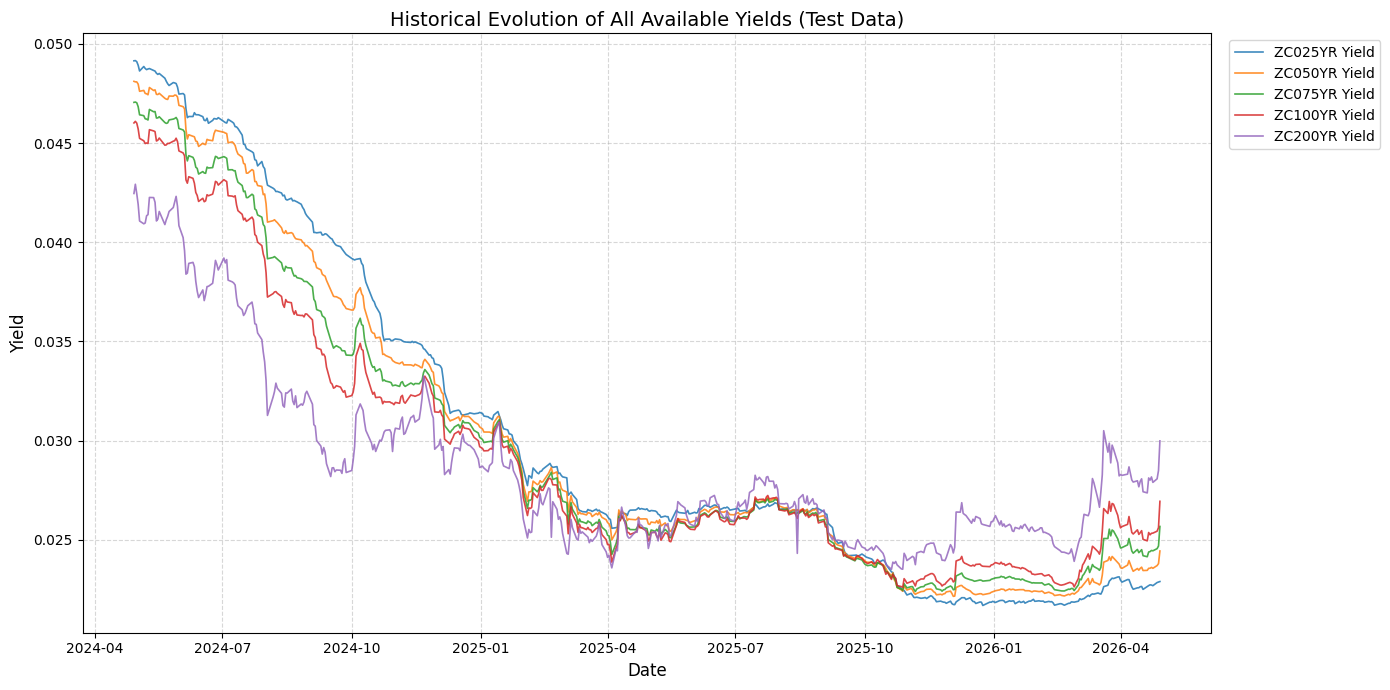

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

print("Loading test data for visualization...")


test_df = pd.read_csv('test_data.csv')
test_df.columns = test_df.columns.str.replace(' ', '', regex=False)
test_df['Date'] = pd.to_datetime(test_df['Date'])
test_df.set_index('Date', inplace=True)

target_columns = ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR',
                  'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']

available_cols = [col for col in target_columns if col in test_df.columns]

plt.figure(figsize=(14, 7))


for col in available_cols:
    plt.plot(test_df.index, test_df[col], label=f'{col} Yield', linewidth=1.2, alpha=0.85)


plt.title('Historical Evolution of All Available Yields (Test Data)', fontsize=14)
plt.ylabel('Yield', fontsize=12)
plt.xlabel('Date', fontsize=12)


plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5.3 The Prediction Challenge: Yield Curve Construction

To evaluate out-of-sample predictive power, we reconstruct the full yield curve (6M through 30Y) using *only* the 3-Month yield as our input proxy for $r_t$.

As given in the pdf, I used the closed-form affine yield formula derived from the CIR framework:
$$y(t,\tau) = \frac{B(t,\tau)r_t - \ln A(t,\tau)}{\tau}$$

Where $A(t,\tau)$ and $B(t,\tau)$ are deterministic functions of our calibrated parameters $(\kappa, \theta, \sigma)$ and the time to maturity $\tau$. No future actuals are exposed to the model during this step.

Then to measure performance we calculate a global R2 measure (flatten all predicted columns i.e make them one data stream), also I calculated individual R2 scores for the different maturities which would later be crucial for analysis and inference.

In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score


print("Loading test datasets...")
test_df = pd.read_csv('test_data.csv')
test_3m_df = pd.read_csv('test_data_3M.csv')

# Aggressively remove any spaces from column headers to prevent KeyErrors
test_df.columns = test_df.columns.str.replace(' ', '', regex=False)
test_3m_df.columns = test_3m_df.columns.str.replace(' ', '', regex=False)


# 2. Setup Inputs and Targets

# r_t is our sole input (the 3-Month yield), extracted directly assuming exact row alignment
r_t_test = test_3m_df['ZC025YR'].values

# The exact tenors we want to predict
expected_targets = ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR',
                    'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
expected_tenors = [0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]

# Safely filter ONLY the columns that successfully loaded from the CSV
target_columns = [col for col in expected_targets if col in test_df.columns]
target_tenors = np.array([expected_tenors[i] for i, col in enumerate(expected_targets) if col in test_df.columns])

if len(target_columns) == 0:
    raise ValueError("Error: None of the target maturity columns were found in the dataset!")

print(f"Successfully found {len(target_columns)} target maturities for testing.")
actual_yields = test_df[target_columns].values


# 3. Yield Reconstruction Function

def predict_yield_curve(kappa, theta, sigma, r_t_array, tenors):
    """Reconstructs the yield curve using Equation 3 from the CIR framework."""
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)

    denominator = (gamma + kappa) * (np.exp(gamma * tenors) - 1) + 2 * gamma
    B = (2 * (np.exp(gamma * tenors) - 1)) / denominator

    numerator_A = 2 * gamma * np.exp((kappa + gamma) * tenors / 2)
    A = (numerator_A / denominator) ** ((2 * kappa * theta) / sigma**2)

    r_t_matrix = r_t_array[:, np.newaxis]
    predicted_yields = (B * r_t_matrix - np.log(A)) / tenors
    return predicted_yields

# 4. Generate Predictions and Score

# Using the parameters from calibration:
kappa_opt = cir_model.kappa
theta_opt = cir_model.theta
sigma_opt = cir_model.sigma

print("Reconstructing yield curves...")
predicted_yields = predict_yield_curve(kappa_opt, theta_opt, sigma_opt, r_t_test, target_tenors)

# Global R^2 Calculation
global_r2 = r2_score(actual_yields.flatten(), predicted_yields.flatten())

print(f"\n======================================")
print(f"OUT-OF-SAMPLE PREDICTION RESULTS")
print(f"======================================")
print(f"Global R^2 Score: {global_r2:.4f}")
print(f"Target to beat:   0.8500")
print(f"======================================\n")

print("--- R^2 Breakdown by Maturity ---")
for i, col in enumerate(target_columns):
    tenor_r2 = r2_score(actual_yields[:, i], predicted_yields[:, i])
    print(f"Maturity {col}: {tenor_r2:.4f}")

Loading test datasets...
Successfully found 4 target maturities for testing.
Reconstructing yield curves...

OUT-OF-SAMPLE PREDICTION RESULTS
Global R^2 Score: 0.9326
Target to beat:   0.8500

--- R^2 Breakdown by Maturity ---
Maturity ZC050YR: 0.9872
Maturity ZC075YR: 0.9752
Maturity ZC100YR: 0.9468
Maturity ZC200YR: 0.6450


## 5.4 D. Model Improvement: The Brigo-Mercurio CIR++ Extension

The base CIR model is fundamentally rigid; its constant parameters force it to converge to a static long-run mean ($\theta$), causing it to systematically fail when the initial term structure is **inverted or humped**, like we saw in this case. To resolve this, we implement the **CIR++ Model** with time-dependent parameters.

We separate the observable market rate $r_t$ into a pure CIR state variable $x_t$ and a deterministic shift $\varphi(t)$:
$$r_t = x_t + \varphi(t)$$

**Implementation Mechanics:**

1. **The Save Point ($t=0$):** We lock the final day of the training set as the initial market curve, defining $P^{MKT}(0,T)$. This acts as a snapshot of the system's state exactly before out-of-sample prediction begins.

2. **Continuous Curve Interpolation:** Because market data is only available at discrete tenors (e.g., 3M, 6M, 1Y), we use linear interpolation (`scipy.interpolate.interp1d`) on the Day 0 yields to build continuous market and base yield curves. This allows us to dynamically fetch yields and calculate zero-coupon bond prices $P(0,t) = e^{-y \cdot t}$ for any arbitrary elapsed time $t$ in the test set.
3. **Isolating the State Variable:** For every test day, we calculate instantaneous forward rates ($f^{MKT}_t$ and $f^{base}_t$) using our interpolated curves and a microscopic time step ($dt = 0.001$), where $f_t \approx -\frac{\ln P(0, t+dt) - \ln P(0, t)}{dt}$. The difference between these forward rates deduces the deterministic shift $\varphi(t)$. By subtracting this shift from the 3M input, we isolate the pure, un-shifted state variable $x_t$ to feed the base prediction engine.
4. **Time-Dependent Price Shift:** Finally, we apply the exact Brigo-Mercurio price multiplier to force the model to respect the initial term structure without introducing data leakage:
$$P^{CIR++}(t,T) = P^{base}(t,T) \times \left( \frac{P^{MKT}(0,T)}{P^{base}(0,T)} \right) \times \left( \frac{P^{base}(0,t)}{P^{MKT}(0,t)} \right)$$
After that we finally calculate the CIR++ yield from this term.

In [9]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from sklearn.metrics import r2_score

print("--- Executing True Brigo-Mercurio CIR++ (Time-Dependent SDE) ---\n")




print("Loading separate test data and 3M input files...")
# Load the 3M Input file
test_3m_df = pd.read_csv('test_data_3M.csv')
test_3m_df.columns = test_3m_df.columns.str.replace(' ', '', regex=False)
test_3m_df['Date'] = pd.to_datetime(test_3m_df['Date'])
test_3m_df.set_index('Date', inplace=True)

# Load the Full Test Actuals file
test_full_df = pd.read_csv('test_data.csv')
test_full_df.columns = test_full_df.columns.str.replace(' ', '', regex=False)
test_full_df['Date'] = pd.to_datetime(test_full_df['Date'])
test_full_df.set_index('Date', inplace=True)

# Ensure target columns exist in the full test dataset
target_columns = [col for col in ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR',
                                  'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
                  if col in test_full_df.columns]

# Map strings back to numerical tenors
tenor_mapping_full = {'ZC025YR': 0.25, 'ZC050YR': 0.5, 'ZC075YR': 0.75, 'ZC100YR': 1.0,
                      'ZC200YR': 2.0, 'ZC500YR': 5.0, 'ZC1000YR': 10.0, 'ZC2000YR': 20.0, 'ZC3000YR': 30.0}
target_tenors = np.array([tenor_mapping_full[col] for col in target_columns])

test_actuals = test_full_df[target_columns].values


# 2. Lock in the Save Point (t=0)

# t=0 is the very last day of the training dataset
save_date = clean_train_df.index[-1]
print(f"Locking Save Point (t=0) at: {save_date.date()}")

all_tenors = np.array([0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
mkt_yields_save = clean_train_df.loc[save_date].values
r_t_save = np.array([clean_train_df.loc[save_date, 'ZC025YR']])

# Calculate Base CIR prediction for Day 0
base_yields_save = predict_yield_curve(kappa_opt, theta_opt, sigma_opt, r_t_save, all_tenors)[0]


# 3. Build Continuous Initial Curves

interp_mkt = interp1d(all_tenors, mkt_yields_save, kind='linear', fill_value="extrapolate")
interp_base = interp1d(all_tenors, base_yields_save, kind='linear', fill_value="extrapolate")

def get_P_0(yield_func, time_point):
    """Calculates P(0, x) from the Save Point."""
    if time_point <= 0:
        return 1.0
    y = yield_func(time_point)
    return np.exp(-y * time_point)


# 4. The Brigo-Mercurio Out-of-Sample Loop

cir_pp_predictions = []
aligned_actuals = []

print("Applying time-dependent price shifts using 3M test inputs...")

# Loop specifically over the 3M input file dates
for test_date, row in test_3m_df.iterrows():



    t = (test_date - save_date).days / 365.25
    r_t_today = np.array([row['ZC025YR']])

    dt = 0.001
    P_mkt_t = get_P_0(interp_mkt, t)
    P_mkt_t_plus = get_P_0(interp_mkt, t + dt)
    f_mkt_t = -(np.log(P_mkt_t_plus) - np.log(P_mkt_t)) / dt

    P_base_t = get_P_0(interp_base, t)
    P_base_t_plus = get_P_0(interp_base, t + dt)
    f_base_t = -(np.log(P_base_t_plus) - np.log(P_base_t)) / dt

    phi_t = f_mkt_t - f_base_t
    x_t_today = np.maximum(r_t_today - phi_t, 1e-6)

    base_yields_today = predict_yield_curve(kappa_opt, theta_opt, sigma_opt, x_t_today, target_tenors)[0]
    P_base_t_T = np.exp(-base_yields_today * target_tenors)

    P_CIR_pp = np.zeros_like(target_tenors)

    for i, tau in enumerate(target_tenors):
        T = t + tau

        P_MKT_0_T  = get_P_0(interp_mkt, T)
        P_base_0_T = get_P_0(interp_base, T)
        P_MKT_0_t  = get_P_0(interp_mkt, t)
        P_base_0_t = get_P_0(interp_base, t)

        multiplier_1 = P_MKT_0_T / P_base_0_T
        multiplier_2 = P_base_0_t / P_MKT_0_t
        P_CIR_pp[i] = P_base_t_T[i] * multiplier_1 * multiplier_2

    yields_pp = -np.log(P_CIR_pp) / target_tenors


    cir_pp_predictions.append(yields_pp)
    aligned_actuals.append(test_full_df.loc[test_date, target_columns].values)

# Convert both to numpy arrays at the end
cir_pp_predictions = np.array(cir_pp_predictions)
test_actuals = np.array(aligned_actuals)


# 5. Evaluate True CIR++ Performance

global_r2_pp = r2_score(test_actuals.flatten(), cir_pp_predictions.flatten())

print(f"\n======================================")
print(f"CIR++ OUT-OF-SAMPLE RESULTS")
print(f"======================================")
print(f"CIR++ Global R^2: {global_r2_pp:.4f}")
print(f"Target to beat:   0.8500")
print(f"======================================\n")

print("--- CIR++ R^2 Breakdown by Maturity ---")
for i, col in enumerate(target_columns):
    tenor_r2_pp = r2_score(test_actuals[:, i], cir_pp_predictions[:, i])
    print(f"Maturity {col}: {tenor_r2_pp:.4f}")

--- Executing True Brigo-Mercurio CIR++ (Time-Dependent SDE) ---

Loading separate test data and 3M input files...
Locking Save Point (t=0) at: 2024-04-26
Applying time-dependent price shifts using 3M test inputs...

CIR++ OUT-OF-SAMPLE RESULTS
CIR++ Global R^2: 0.9378
Target to beat:   0.8500

--- CIR++ R^2 Breakdown by Maturity ---
Maturity ZC050YR: 0.9925
Maturity ZC075YR: 0.9750
Maturity ZC100YR: 0.9406
Maturity ZC200YR: 0.6855


## 5.5 Critical Analysis & Real-World Implications

### **Results Summary**

**Base CIR R2 scores:**

Global R^2 Score: **0.9326**  

Maturity ZC050YR: 0.9872   
Maturity ZC075YR: 0.9752  
Maturity ZC100YR: 0.9468  
Maturity ZC200YR: 0.6450  


**CIR++ R2 scores:**

Global R^2 Score: **0.9378**

Maturity ZC050YR: 0.9925  
Maturity ZC075YR: 0.9750  
Maturity ZC100YR: 0.9406  
Maturity ZC200YR: 0.6855  
  
The base CIR model achieved high accuracy on the short end of the curve but suffered severe degradation on longer maturities (e.g., 2-Year). The CIR++ extension, absorbed the structural bias via the initial term structure shift, the main increase was in the later term of 200YR (about 0.04) as it took in the change between predicted and real values there was on day 0. While also giving a slight increase on global R2.

### **Theoretical and Practical Limitations**

**1. Limitations of the Base CIR Model:**
* *Theoretical:* It assumes a constant speed of mean reversion ($\kappa$) and a static long-run mean ($\theta$). It assumes rates will constantly pull back to a single historical average.
* *Practical:* In a real-world trading scenario, macroeconomic regime shifts (e.g., sudden hyperinflation or zero-interest-rate policies) render historical means obsolete. A base CIR model would consistently misprice long-term derivatives during a structural market pivot.

**2. Limitations of the CIR++ Model:**
* *Theoretical:* While it perfectly fits the initial yield curve (Day 0), the volatility structure remains governed by the base $\sigma$. The deterministic shift $\varphi(t)$ corrects the *level* of rates, but not the dynamics of their variance.
* *Practical:* In a derivatives pricing context, CIR++ is highly favored because exact initial curve fitting prevents Day-1 arbitrage opportunities. However, for long-term risk management (e.g., Value at Risk), relying on a static Day 0 curve to dictate future shifts becomes dangerous if market expectations abruptly change weeks into the forecast period.